# HW4: Palmer Penguins — Summary Statistics & Plots

### Setup

- Use only `pandas`, `matplotlib`, and `seaborn`.
- Do your work in the cells provided; you may add extra cells.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) nicer display for DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)


In [2]:
### Load the dataset
penguins = pd.read_csv("penguins.csv")

# Standardize column names (snake_case)
penguins.columns = [c.strip().lower().replace(' ', '_') for c in penguins.columns]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Part 1) Data Vitals

Answer the following questions.

Your answer to each question must include some code that produces the result. You can, but you do not have to use a complete sentence to answer each question. Add cells as needed.

- a. What is the shape of the data?
- b. What are the Column names and data types of each column?
- c. How many values in each column are missing?
- d. How many penguins are there of each species? How many male and female penguins are there?

In [10]:
# Your code here
print(penguins.shape)


(344, 8)


a) The data has 344 rows and 8 columns

In [14]:
print(penguins.columns)
print(penguins.dtypes)

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='str')
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object


b) the column names are 'species', 'island', 'bill_length_mm', 'bill_depth_mm' 'flipper_length_mm', 'body_mass_g', 'sex', and 'year'.

The respective data types are str, str, float, float, float, float, str, and int.

In [18]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

c) there are 2 values missing in the bill_length_mm, bill_depth_mm, flipper_length__mm, and body_mass_g columns and 11 values missing in the sex column.

In [23]:
print(penguins.loc[:, 'species'].value_counts())
print(penguins.loc[:, 'sex'].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
sex
male      168
female    165
Name: count, dtype: int64


d) There are 152 Adelie penguins, 124 Gentoo penguins, and 68 Chinstrap penguins. There are 168 males and 165 females.

### Part 2) Handle missing data

- a. Create a copy `penguins_clean` that **drops** rows with missing values in
   `['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']`.  
- b. Report the new shape of `penguins_clean`.


In [ ]:
# Your code here
penguins_clean = penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex'])

(333, 8)

In [41]:
penguins_clean.shape

(333, 8)

b) the penguins_clean data frame has 8 columns and 333 rows

### Part 3) Numeric summary statistics

- a. Compute the following **for each numeric column**: count, mean, std, min, 25%, 50%, 75%, max (hint: `.describe()`)
- b. Compute the mean and std for each numeric column for each `species`

In [42]:
# Your code here
penguins_clean.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000,333.000,333.000,333.000,333.000
mean,43.993,17.165,200.967,4207.057,2008.042
std,5.469,1.969,14.016,805.216,0.813
min,32.100,13.100,172.000,2700.000,2007.000
25%,39.500,15.600,190.000,3550.000,2007.000
50%,44.500,17.300,197.000,4050.000,2008.000
75%,48.600,18.700,213.000,4775.000,2009.000
max,59.600,21.500,231.000,6300.000,2009.000


In [55]:
penguins_clean.loc[:,['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']].groupby(penguins_clean['species']).agg([np.mean, np.std])

bill_length_mm        bill_depth_mm        flipper_length_mm         \
                    mean    std          mean    std              mean    std   
species                                                                         
Adelie            38.824  2.653        18.347  1.215           190.103  6.499   
Chinstrap         48.834  3.315        18.421  1.127           195.824  7.079   
Gentoo            47.568  3.093        14.997  0.982           217.235  6.558   

          body_mass_g               year         
                 mean      std      mean    std  
species                                          
Adelie       3706.164  457.047  2008.055  0.809  
Chinstrap    3733.088  381.499  2007.971  0.857  
Gentoo       5092.437  499.365  2008.067  0.786

### Part 4) Two-way grouped summaries

a) For each **(species, sex)** combination, compute the **mean** and **count** of:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

b) Which (species, sex) has the **largest average body_mass_g**? Show the row.



In [67]:
# Your code here
grouped_summary=penguins_clean.loc[:, ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].groupby([penguins_clean['species'], penguins_clean['sex']]).agg(['mean', 'count'])
print(grouped_summary)

                 bill_length_mm       bill_depth_mm       flipper_length_mm  \
                           mean count          mean count              mean   
species   sex                                                                 
Adelie    female         37.258    73        17.622    73           187.795   
          male           40.390    73        19.073    73           192.411   
Chinstrap female         46.574    34        17.588    34           191.735   
          male           51.094    34        19.253    34           199.912   
Gentoo    female         45.564    58        14.238    58           212.707   
          male           49.474    61        15.718    61           221.541   

                       body_mass_g        
                 count        mean count  
species   sex                             
Adelie    female    73    3368.836    73  
          male      73    4043.493    73  
Chinstrap female    34    3527.206    34  
          male      34    3938

In [89]:
biggest_mass=penguins_clean.groupby(['species', 'sex'])['body_mass_g'].mean().sort_values(ascending=False)
biggest_mass.head(1)

species  sex 
Gentoo   male    5484.836
Name: body_mass_g, dtype: float64

b) the gentoo male has the largest mean body mass of 5484.836 grams.

### Part 5) Correlations

- a. Compute the **correlation matrix** among numeric columns.  
- b. Compute the correlation matrix **within each species** (hint: groupby).  
- c. Find an example of Simpson's Paradox in the data. https://en.wikipedia.org/wiki/Simpson%27s_paradox  
        - An example Simpson's Paradox would be a pair of variables that have a positive correlation within subgroups, but when all the groups are combined, there is negative correlation (or vice-versa). 

In [106]:
# Your code here
penguins_clean[['bill_depth_mm', 'bill_length_mm', 'flipper_length_mm', 'body_mass_g', 'year']].corr()

,bill_depth_mm,bill_length_mm,flipper_length_mm,body_mass_g,year
bill_depth_mm,1.000,-0.229,-0.578,-0.472,-0.048
bill_length_mm,-0.229,1.000,0.653,0.589,0.033
flipper_length_mm,-0.578,0.653,1.000,0.873,0.151
body_mass_g,-0.472,0.589,0.873,1.000,0.022
year,-0.048,0.033,0.151,0.022,1.000


In [105]:
penguins_clean[['bill_depth_mm', 'bill_length_mm', 'flipper_length_mm', 'body_mass_g', 'year']].groupby(penguins_clean['species']).corr()

bill_depth_mm  bill_length_mm  flipper_length_mm  \
species                                                                         
Adelie    bill_depth_mm              1.000           0.386              0.311   
          bill_length_mm             0.386           1.000              0.332   
          flipper_length_mm          0.311           0.332              1.000   
          body_mass_g                0.580           0.544              0.465   
          year                      -0.235           0.011              0.328   
Chinstrap bill_depth_mm              1.000           0.654              0.580   
          bill_length_mm             0.654           1.000              0.472   
          flipper_length_mm          0.580           0.472              1.000   
          body_mass_g                0.604           0.514              0.642   
          year                      -0.059           0.042              0.346   
Gentoo    bill_depth_mm              1.000           0.654              0.711   
          bill_length_mm             0.654           1.000              0.664   
          flipper_length_mm          0.711           0.664              1.000   
          body_mass_g                0.723           0.667              0.711   
          year                       0.243           0.205              0.201   

                             body_mass_g   year  
species                                          
Adelie    bill_depth_mm            0.580 -0.235  
          bill_length_mm           0.544  0.011  
          flipper_length_mm        0.465  0.328  
          body_mass_g              1.000 -0.046  
          year                    -0.046  1.000  
Chinstrap bill_depth_mm            0.604 -0.059  
          bill_length_mm           0.514  0.042  
          flipper_length_mm        0.642  0.346  
          body_mass_g              1.000  0.037  
          year                     0.037  1.000  
Gentoo    bill_depth_mm            0.723  0.243  
          bill_length_mm           0.667  0.205  
          flipper_length_mm        0.711  0.201  
          body_mass_g              1.000  0.052  
          year                     0.052  1.000

In [108]:
penguins_clean[['bill_depth_mm', 'bill_length_mm', 'flipper_length_mm', 'body_mass_g', 'year']].corr()

,bill_depth_mm,bill_length_mm,flipper_length_mm,body_mass_g,year
bill_depth_mm,1.000,-0.229,-0.578,-0.472,-0.048
bill_length_mm,-0.229,1.000,0.653,0.589,0.033
flipper_length_mm,-0.578,0.653,1.000,0.873,0.151
body_mass_g,-0.472,0.589,0.873,1.000,0.022
year,-0.048,0.033,0.151,0.022,1.000


An example of Simpson's paradox can be found in the correlation between bill_depth_mm and bill_length_mm. When the data is grouped by species, the correlation is positive for each species (0.386, 0.654, and 0.654 respectively). When the groups are combined, the correlation is negative (-0.229)

## Plots

- Each figure must have a **title**, **axis labels**, and a **legend** (when appropriate).
- Use readable tick labels and sensible limits.
- Be sure each graphic is displayed.

### Part 6) Histograms of body mass by species

Create **separate** histograms of `body_mass_g` for each species (three panels).
    
- Use the same binning across panels so comparisons are fair.  
- Label axes clearly


Text(0, 0.5, 'Body Mass (g)')

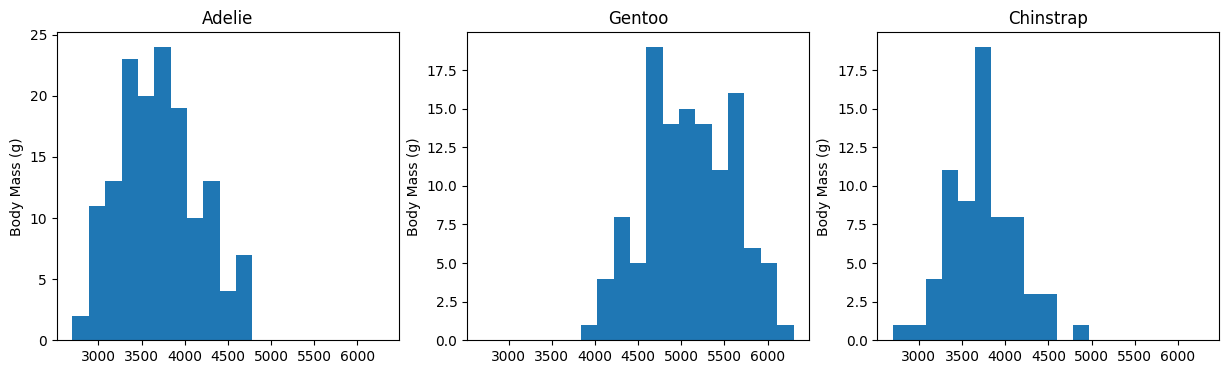

In [202]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
adelie_mass=penguins_clean[penguins_clean['species']=='Adelie']['body_mass_g']
gentoo_mass=penguins_clean[penguins_clean['species']=='Gentoo']['body_mass_g']
chinstrap_mass=penguins_clean[penguins_clean['species']=='Chinstrap']['body_mass_g']
bins=np.linspace(penguins_clean['body_mass_g'].min(), penguins_clean['body_mass_g'].max(), 20)

axes[0].hist(adelie_mass, bins=bins)
axes[1].hist(gentoo_mass, bins=bins)
axes[2].hist(chinstrap_mass, bins=bins)

axes[0].set_title('Adelie')
axes[1].set_title('Gentoo')
axes[2].set_title('Chinstrap')

axes[0].set_ylabel('Body Mass (g)')
axes[1].set_ylabel('Body Mass (g)')
axes[2].set_ylabel('Body Mass (g)')



### Part 7) Boxplots of flipper length

Make a **single figure** with boxplots of `flipper_length_mm` by **species**.  

Briefly compare the medians and spreads in 2–3 sentences in a markdown cell.

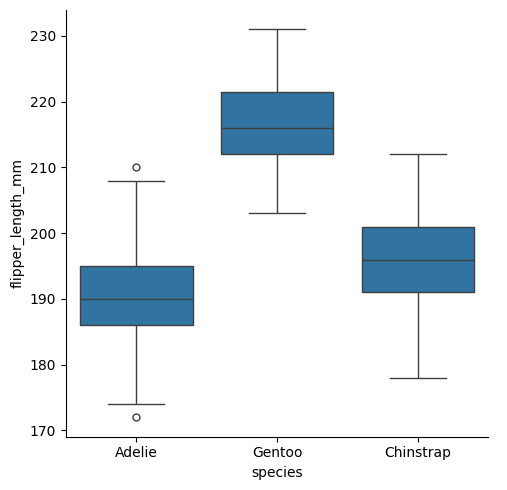

In [137]:
sns.catplot(data=penguins_clean, x='species', y='flipper_length_mm', kind='box')

Adelie penguins have the lowest flipper length median, Chinstrap penguins have the second lowest flipper length median, and Gentoo penguins have the highest flipper length median. The spread of all three species appears to be similar.

### Part 8) Scatter: bill length vs bill depth

- Make a scatter plot of **bill_length_mm** (x) vs **bill_depth_mm** (y), colored by species.
- Add a simple **linear fit line** per species
- Include a legend 

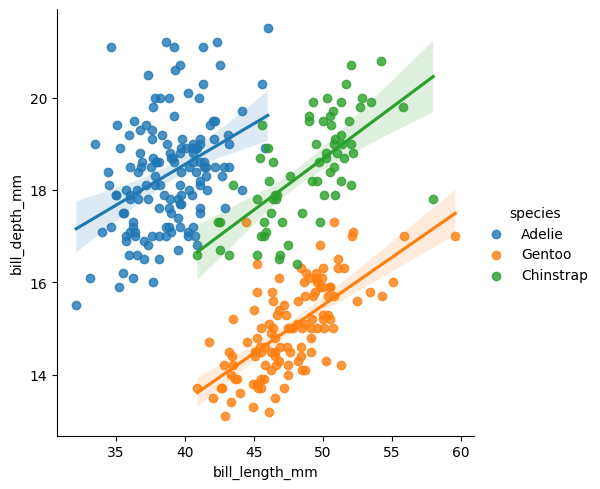

In [140]:
sns.lmplot(data=penguins_clean, x='bill_length_mm', y='bill_depth_mm', hue='species')

### Part 9) Stacked bars: sex proportions by species

Compute counts of `sex` within each `species`, convert to **proportions**, and make a **stacked bar chart**.  

- Bars should be species on the x‑axis with male/female proportions stacked to 1.0. 

<Axes: >

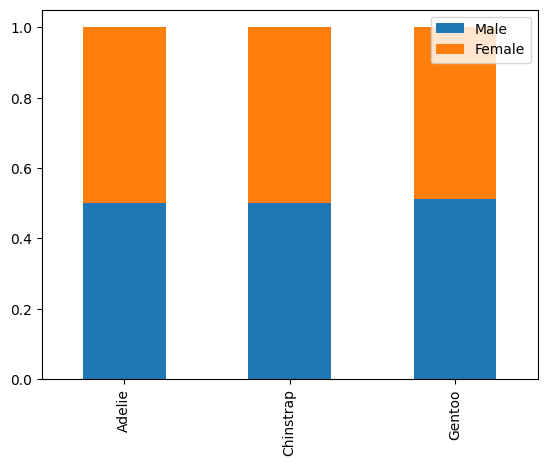

In [191]:
gender_counts=penguins_clean.groupby(['species', 'sex'])['species'].value_counts()
adelie_f=gender_counts.Adelie['female']/sum(gender_counts.Adelie)
adelie_m=gender_counts.Adelie['male']/sum(gender_counts.Adelie)
chinstrap_f=gender_counts.Chinstrap['female']/sum(gender_counts.Chinstrap)
chinstrap_m=gender_counts.Chinstrap['male']/sum(gender_counts.Chinstrap)
gentoo_f=gender_counts.Gentoo['female']/sum(gender_counts.Gentoo)
gentoo_m=gender_counts.Gentoo['male']/sum(gender_counts.Gentoo)

gender_prop=pd.DataFrame({
    'Male':[adelie_m, chinstrap_m, gentoo_m],
    'Female':[adelie_f, chinstrap_f, gentoo_f]
}, index=['Adelie', 'Chinstrap', 'Gentoo'])
gender_prop.plot(kind='bar', stacked=True)

In [190]:
gender_prop

,Male,Female
0,0.500,0.500
1,0.500,0.500
2,0.513,0.487
